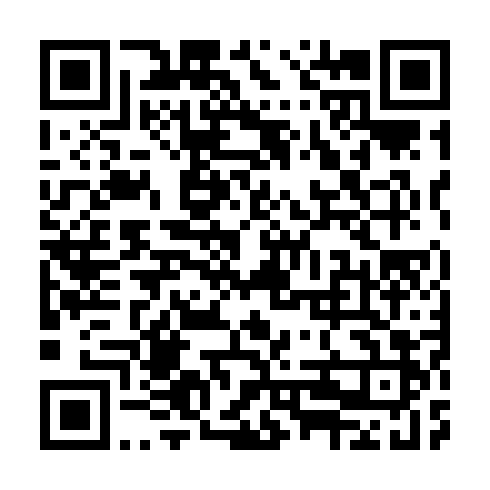

image.png

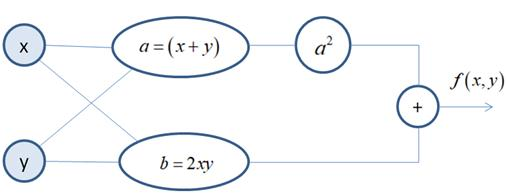

In [ ]:
import torch
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(-4.0, requires_grad=True)
f = (x+y)**2 + 2*x*y
f.backward()
print(x.grad)
print(y.grad)

tensor(-12.)
tensor(0.)


In [ ]:
import tensorflow as tf

x = tf.Variable([[2.0]])
y = tf.Variable([[-4.0]])

with tf.GradientTape() as tape:
  f = (x + y)**2 + 2*x*y

df = tape.gradient(f, [x, y])

print(df[0], df[1], sep="\n")

tf.Tensor([[-12.]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.]], shape=(1, 1), dtype=float32)


Часть описывающая доступ к датаесету MNIST мы не будем ее трогать

(50000, 784)


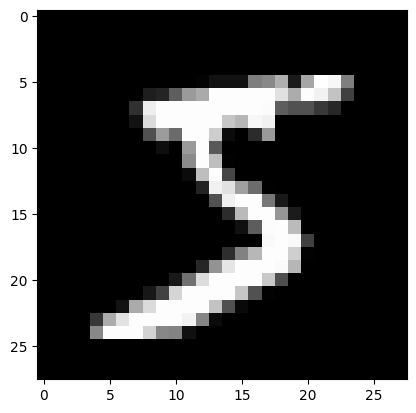

In [ ]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)
import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

Преобразуем входные данные в тензоры pytorсh

In [ ]:
import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)
n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


<ipython-input-100-67dd6265e0f9>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train, y_train, x_valid, y_valid = map(


Генерируем тензор с весами для будущей модели

In [ ]:
import math

weights = torch.randn(784, 10) / math.sqrt(784)
print(weights.shape)
print(weights)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)
print(bias)

torch.Size([784, 10])
tensor([[-0.0137, -0.0287, -0.0001,  ...,  0.0448, -0.0050,  0.0295],
        [ 0.0092, -0.0378, -0.0284,  ...,  0.0103,  0.0852, -0.0097],
        [-0.0523, -0.0162,  0.0138,  ...,  0.0310, -0.0077, -0.0262],
        ...,
        [ 0.0769, -0.0023, -0.0098,  ..., -0.0014, -0.0434, -0.0456],
        [ 0.0008,  0.0567,  0.0330,  ...,  0.0025,  0.0234, -0.0092],
        [-0.0514,  0.0157, -0.0115,  ...,  0.0121,  0.0302,  0.0040]])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)


Pytorch может использовать для рассчета градиентов любую функцию реализованую средствами Pyhon.
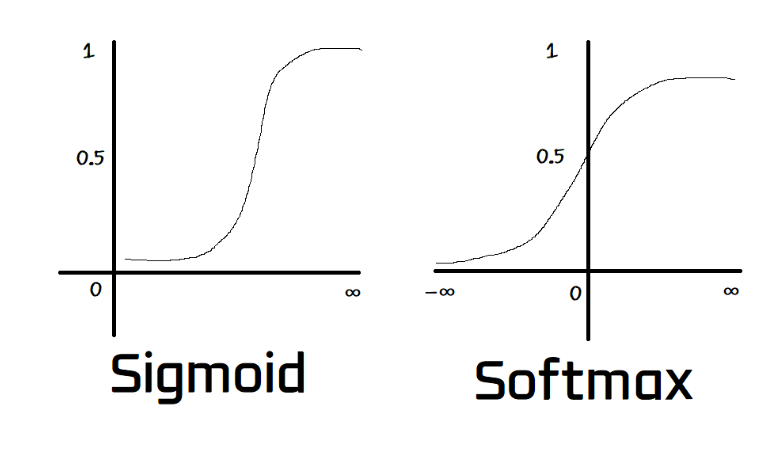

In [ ]:
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
    return log_softmax(xb @ weights + bias)

В приведенном выше примере @ обозначает операцию умножения матрицы. Мы вызовем нашу функцию для одного пакета данных (в данном случае 64 изображений). Это один проход вперед. Обратите внимание, что на этом этапе наши прогнозы не будут лучше случайных, поскольку мы начинаем со случайных весов.

In [ ]:
bs = 64  # batch size

xb = x_train[0:bs]  # a mini-batch from x
preds = model(xb)  # predictions
preds[0], preds.shape
print(preds[0], preds.shape)

tensor([-2.3723, -2.2165, -2.4644, -2.0520, -2.1113, -1.8460, -2.8369, -2.8442,
        -2.6964, -2.1119], grad_fn=<SelectBackward0>) torch.Size([64, 10])


задаем функцию потерь для модели

In [ ]:
def nll(input, target):
    return -input[range(target.shape[0]), target].mean()

loss_func = nll

In [ ]:
yb = y_train[0:bs]
#print(yb)
#print(preds)
print(loss_func(preds, yb))

tensor(2.2930, grad_fn=<NegBackward0>)


In [ ]:
функция для расчета точности

In [ ]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

In [ ]:
print(torch.argmax(preds, dim=1))
print(yb)

print(accuracy(preds, yb))

tensor([5, 5, 5, 9, 3, 5, 3, 5, 3, 7, 3, 7, 5, 5, 3, 5, 5, 9, 1, 3, 9, 5, 3, 9,
        9, 9, 9, 5, 5, 5, 3, 9, 5, 5, 5, 9, 9, 5, 9, 5, 7, 9, 7, 5, 3, 9, 9, 9,
        3, 3, 3, 5, 9, 5, 9, 9, 3, 5, 5, 9, 1, 5, 5, 5])
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1,
        1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9, 3, 9, 8, 5,
        9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0])
tensor(0.1406)


Запускаем цикл обучения
  

*   выбираем пакет данных
*   отправляем на вход модели
*   Считаем ошибку
*   считаем градиент, обнавляем веса и смещения




In [ ]:
from IPython.core.debugger import set_trace

lr = 0.5  # learning rate
epochs = 2  # how many epochs to train for

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        #         set_trace()
        start_i = i * bs
        end_i = start_i + bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)
        #print(loss)

        loss.backward()
        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            weights.grad.zero_()
            bias.grad.zero_()

In [ ]:
print(loss_func(model(xb), yb))
print( accuracy(model(xb), yb))

tensor(0.0655, grad_fn=<NegBackward0>)
tensor(1.)


In [ ]:
xb = x_train[0:bs]  # a mini-batch from x
preds = model(xb)
print(torch.argmax(preds, dim=1))
yb = y_train[0:bs]
print(yb)

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1,
        1, 2, 4, 3, 7, 7, 3, 8, 6, 7, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9, 3, 9, 8, 5,
        5, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0])
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1,
        1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9, 3, 9, 8, 5,
        9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0])


In [ ]:
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms


def create_nn(batch_size=200, learning_rate=0.01, epochs=5,
              log_interval=10):

    train_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=True, download=True,
                       transform=transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize((0.1307,), (0.3081,))
                       ])),
        batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(
        datasets.MNIST('../data', train=False, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])),
        batch_size=batch_size, shuffle=True)

    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(28 * 28, 200)
            self.fc2 = nn.Linear(200, 200)
            self.fc3 = nn.Linear(200, 10)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return F.log_softmax(x)

    net = Net()
    print(net)

    # create a stochastic gradient descent optimizer
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    # create a loss function
    criterion = nn.NLLLoss()

    # run the main training loop
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = Variable(data), Variable(target)
            # resize data from (batch_size, 1, 28, 28) to (batch_size, 28*28)
            data = data.view(-1, 28*28)
            optimizer.zero_grad()
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()
            if batch_idx % log_interval == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, batch_idx * len(data), len(train_loader.dataset),
                           100. * batch_idx / len(train_loader), loss.data))

    # run a test loop
    test_loss = 0
    correct = 0
    for data, target in test_loader:
        data, target = Variable(data, volatile=True), Variable(target)
        data = data.view(-1, 28 * 28)
        net_out = net(data)
        # sum up batch loss
        test_loss += criterion(net_out, target).data
        pred = net_out.data.max(1)[1]  # get the index of the max log-probability
        correct += pred.eq(target.data).sum()

    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))


if __name__ == "__main__":
    run_opt = 2
    if run_opt == 1:
        simple_gradient()
    elif run_opt == 2:
        create_nn()

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 16602034.48it/s]


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 487911.32it/s]


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 4567480.30it/s]


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 12362445.66it/s]
<ipython-input-133-689d33195a1c>:37: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw

Net(
  (fc1): Linear(in_features=784, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (fc3): Linear(in_features=200, out_features=10, bias=True)
)
Train Epoch: 0 [0/60000 (0%)]	Loss: 2.305163
Train Epoch: 0 [2000/60000 (3%)]	Loss: 2.196106
Train Epoch: 0 [4000/60000 (7%)]	Loss: 1.874010
Train Epoch: 0 [6000/60000 (10%)]	Loss: 1.388672
Train Epoch: 0 [8000/60000 (13%)]	Loss: 0.743438
Train Epoch: 0 [10000/60000 (17%)]	Loss: 0.514614
Train Epoch: 0 [12000/60000 (20%)]	Loss: 0.495891
Train Epoch: 0 [14000/60000 (23%)]	Loss: 0.401493
Train Epoch: 0 [16000/60000 (27%)]	Loss: 0.458015
Train Epoch: 0 [18000/60000 (30%)]	Loss: 0.369315
Train Epoch: 0 [20000/60000 (33%)]	Loss: 0.295764
Train Epoch: 0 [22000/60000 (37%)]	Loss: 0.364124
Train Epoch: 0 [24000/60000 (40%)]	Loss: 0.235700
Train Epoch: 0 [26000/60000 (43%)]	Loss: 0.250429
Train Epoch: 0 [28000/60000 (47%)]	Loss: 0

<ipython-input-133-689d33195a1c>:67: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data, target = Variable(data, volatile=True), Variable(target)



Test set: Average loss: 0.0005, Accuracy: 9715/10000 (97%)

